In [ ]:
pip install -r requirements.txt

# Bivariate analysis

In univariate analysis we only looked at 1 variable (= 1 column) at a time. In bivariate analysis we will now look at the relation between two variables (= 2 columns).

The type of analysis we can do will once again depend on the types of data of these 2 variables. We look look at:
- Numerical VS Numerical.
- Nummerical VS Categorical
- Categorical VS Categorical

## Numerical vs Numerical

Examples:
- Body length VS Shoe size
- Age VS Seconds it takes to run 1 kilometre
- Country Unemployment rate VS Country Happiness Rating
- Customer Revenue VS Customer Lifetime
- Game Wishlists VS Game Purchases
- Student grades VS Student attendance
- ...


Let's load the Iris dataset again and explore this!

In [1]:
import seaborn as sns
import pandas as pd

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


![](https://miro.medium.com/max/1000/1*Hh53mOF4Xy4eORjLilKOwA.png "Iris dataset") 

Let's look at the relation between the sepal length and petal length. (Dutch: Kelkblad en bloemblad)

We will do this with a **scatter plot**.
A scatter plot is a type of graph used to display the relationship between two numerical variables. Each point on the graph represents one observation from your dataset, with:

The x-axis showing values of one variable (sepal_length)
The y-axis showing values of another variable (petal_length)

So, in this example, each dot represents a flower from the Iris dataset, positioned according to its sepal_length and petal_length.


Scatter plots are useful for:
- Spotting correlations or relationships between variables
- Identifying clusters, trends, or outliers

<Axes: xlabel='sepal_length', ylabel='petal_length'>

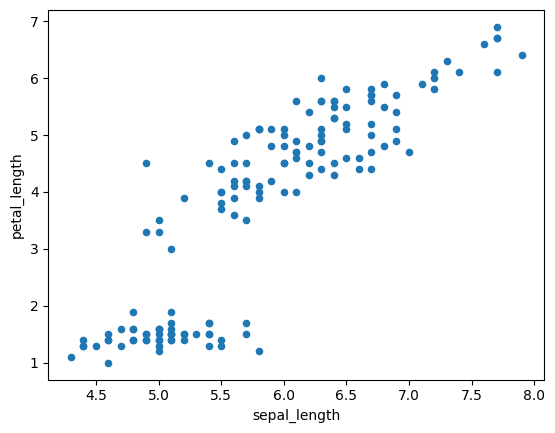

In [2]:
iris.plot(kind='scatter', x='sepal_length', y='petal_length')

A useful statistic for calculating the linear relation between two variable is the **Pearson correlation**.  
The Pearson correlation measures the linear relation between two numerical variables. The result is a number between -1 and 1 where
- -1 indicates a perfect negative linear relation
- 0 indicates that there is no linear relation
- 1 indicates a perfect positive linear relation

![](https://www.spss-tutorials.com/img/correlation-coefficient-multiple-scatterplots.png "Pearson correlation examples")

![](https://cdn1.byjus.com/wp-content/uploads/2019/06/word-image28.png "Pearson correlation formula")

In [3]:
iris[['sepal_length','petal_length']].corr() # print the correlation coefficient for the two columns

,sepal_length,petal_length
sepal_length,1.000000,0.871754
petal_length,0.871754,1.000000


Let's print this for all the columns:

In [4]:
irisCorrelations = iris.corr()

ValueError: could not convert string to float: 'setosa'

Why is this not working?
This is the error:

```ValueError: could not convert string to float: 'setosa'```

In [5]:
irisCorrelations = iris.corr(numeric_only=True) # Only include numeric columns
irisCorrelations.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2) # Format the output, precision is the number of decimal places

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


<Axes: xlabel='sepal_width', ylabel='petal_length'>

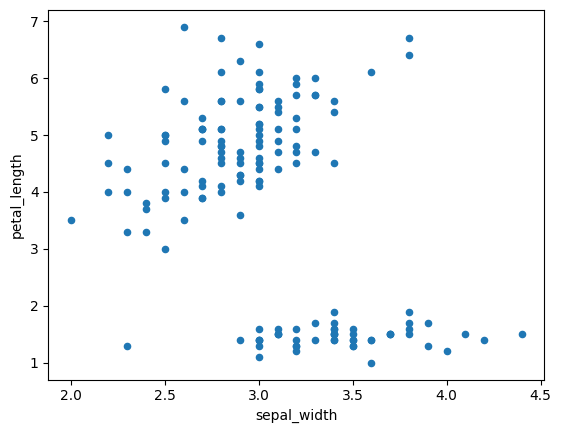

In [6]:
iris.plot(kind='scatter', x='sepal_width', y='petal_length')

**What is NumPy?**
NumPy (short for Numerical Python) is a powerful Python library used for numerical computing. It provides support for:
- Multi-dimensional arrays (called ndarray)
- Mathematical operations on arrays (e.g., sum, mean, dot product, etc.)
- Linear algebra, random number generation, Fourier transforms, and more

In [7]:
import numpy as np

In [11]:
exampleData = pd.Series(range(100)) + 1 # Create a series of numbers from 1 to 100
exampleDataNegative = -exampleData
exampleDataDouble = exampleData * 2
exampleDataSquared = exampleData ** 2
exampleDataRoot = exampleData ** 0.5

exampleDataExponential = 2 ** exampleData
exampleDataLog = np.log2(exampleData)

exampleDataWithSmallNoise = exampleData + np.random.randint(low=0, high=10, size=len(exampleData))
exampleDataWithMediumNoise = exampleData + np.random.randint(low=0, high=100, size=len(exampleData))
exampleDataWithHeavyNoise = exampleData + np.random.randint(low=0, high=1000, size=len(exampleData))

exampleDataFrame = pd.DataFrame({'original':exampleData, 'negative':exampleDataNegative, 'double':exampleDataDouble, 'squared':exampleDataSquared, 'root': exampleDataRoot, 'exp':exampleDataExponential, 'log':exampleDataLog, 'noiseSmall': exampleDataWithSmallNoise, 'noiseMedium': exampleDataWithMediumNoise, 'noiseHeavy':exampleDataWithHeavyNoise })

In [12]:
exampleDataFrame.head()

,original,negative,double,squared,root,exp,log,noiseSmall,noiseMedium,noiseHeavy
0,1,-1,2,1,1.000000,2,0.000000,6,42,176
1,2,-2,4,4,1.414214,4,1.000000,9,60,814
2,3,-3,6,9,1.732051,8,1.584963,3,71,674
3,4,-4,8,16,2.000000,16,2.000000,13,33,262
4,5,-5,10,25,2.236068,32,2.321928,8,39,414


In [15]:
exampleDataCorrelations = exampleDataFrame.corr(numeric_only=True)
exampleDataCorrelations.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,original,negative,double,squared,root,exp,log,noiseSmall,noiseMedium,noiseHeavy
original,1.00,-1.00,1.00,0.97,0.98,-0.01,0.90,1.00,0.73,0.13
negative,-1.00,1.00,-1.00,-0.97,-0.98,0.01,-0.90,-1.00,-0.73,-0.13
double,1.00,-1.00,1.00,0.97,0.98,-0.01,0.90,1.00,0.73,0.13
squared,0.97,-0.97,0.97,1.00,0.91,-0.01,0.78,0.96,0.69,0.11
root,0.98,-0.98,0.98,0.91,1.00,-0.00,0.96,0.98,0.72,0.14
exp,-0.01,0.01,-0.01,-0.01,-0.00,1.00,-0.00,-0.02,0.08,-0.02
log,0.90,-0.90,0.90,0.78,0.96,-0.00,1.00,0.89,0.66,0.14
noiseSmall,1.00,-1.00,1.00,0.96,0.98,-0.02,0.89,1.00,0.72,0.13
noiseMedium,0.73,-0.73,0.73,0.69,0.72,0.08,0.66,0.72,1.00,0.08
noiseHeavy,0.13,-0.13,0.13,0.11,0.14,-0.02,0.14,0.13,0.08,1.00


<Axes: >

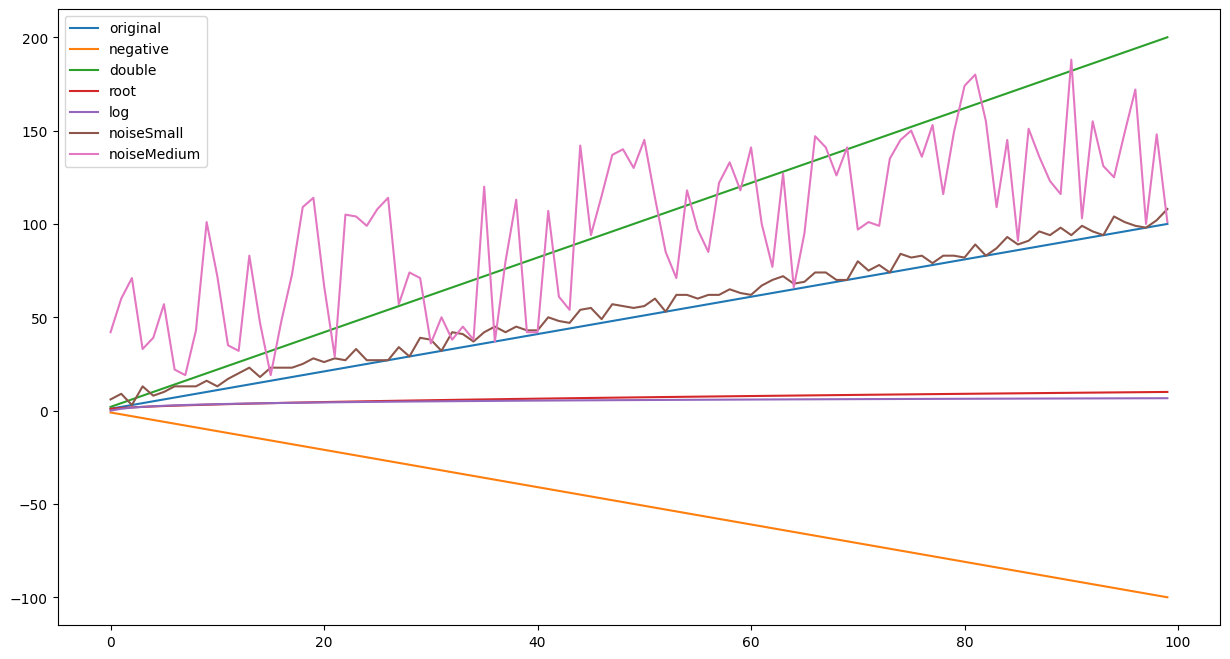

In [16]:
# Excluding a couple of columns because their values are too high to show in the same plot
exampleDataFrame.drop(['exp', 'squared' , 'noiseHeavy'], axis=1).plot(figsize=(15,8))

### Portfolio assignment 9
25 min: Perform a bivariate analysis on the columns with numerical data in the penguins dataset.
- Use corr() on the DataFrame to calculate all the correlations. Use the code example above to show the correlation table with colors.
- Look at the corrrelations. Do they match your expectations?
- Show a scatter plot for:
   - The strongest positive correlation
   - The strongest negative correlation
   - The weakest correlation

In [17]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [18]:
penguinsCorrelations = penguins.corr(numeric_only=True) # Only include numeric columns
penguinsCorrelations.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2) # Format the output, precision is the number of decimal places

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


<Axes: xlabel='body_mass_g', ylabel='flipper_length_mm'>

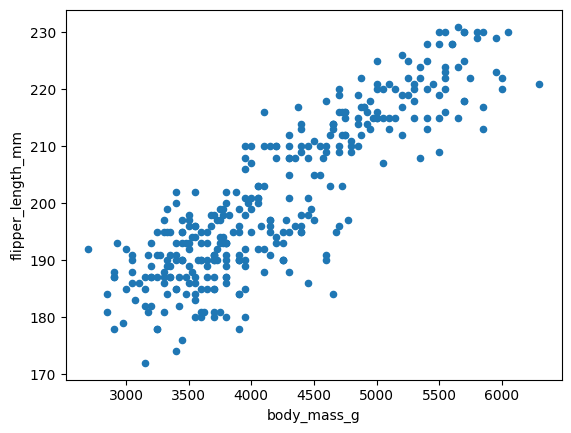

In [19]:
penguins.plot(kind='scatter', x='body_mass_g', y='flipper_length_mm')

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

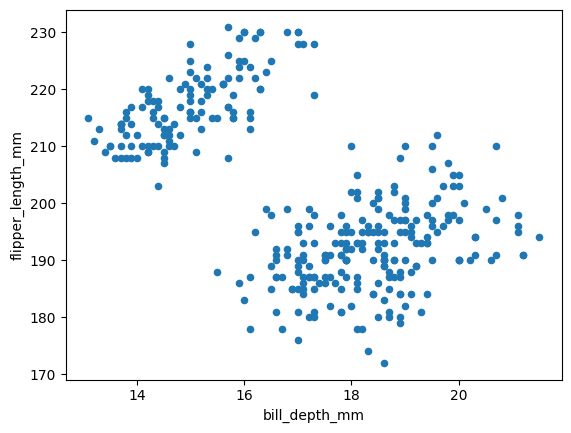

In [20]:
penguins.plot(kind='scatter', x='bill_depth_mm', y='flipper_length_mm')

<Axes: xlabel='bill_depth_mm', ylabel='bill_length_mm'>

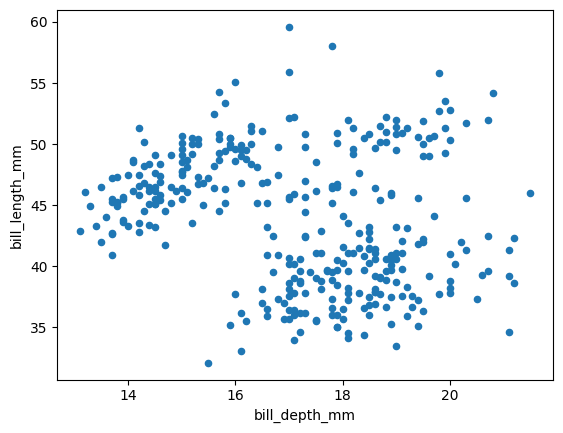

In [21]:
penguins.plot(kind='scatter', x='bill_depth_mm', y='bill_length_mm')

![](https://user-images.githubusercontent.com/54525819/139198017-769e8f61-2e58-48a9-947d-fd22947a6548.png)

![](https://i.imgur.com/0v1CGNV.png)<br>
Assumption: ...<br>
Findings: ...<br>

### Portfolio assignment 10
15 min: Perform a bivariate analysis (Pearson correlation and scatter plot) on at least 1 combination of 2 columns with numeric data in the dataset that you chose in portfolio assignment 4. Does the correlation and scatter plot match your expectations? Add your answer to your notebook. Commit the Notebook to your portfolio when you're finished. 

![](https://i.imgur.com/0v1CGNV.png)<br>
Assumption: ...<br>
Findings: ...<br>

In [23]:
animeCorrelations = topRatedAnime.corr(numeric_only=True)
animeCorrelations.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,mal_id,episodes,airing,score,scored_by,rank,popularity,members,favorites,year
mal_id,1.00,-0.17,0.20,0.11,-0.16,-0.13,0.32,-0.18,-0.22,0.89
episodes,-0.17,1.00,0.10,0.04,0.16,-0.02,0.04,0.17,0.28,-0.38
airing,0.20,0.10,1.00,0.01,-0.10,-0.02,0.24,-0.10,0.00,0.15
score,0.11,0.04,0.01,1.00,0.27,-0.95,-0.19,0.28,0.35,0.09
scored_by,-0.16,0.16,-0.10,0.27,1.00,-0.25,-0.47,0.99,0.81,-0.03
rank,-0.13,-0.02,-0.02,-0.95,-0.25,1.00,0.17,-0.26,-0.29,-0.10
popularity,0.32,0.04,0.24,-0.19,-0.47,0.17,1.00,-0.52,-0.33,-0.01
members,-0.18,0.17,-0.10,0.28,0.99,-0.26,-0.52,1.00,0.83,-0.05
favorites,-0.22,0.28,0.00,0.35,0.81,-0.29,-0.33,0.83,1.00,-0.18
year,0.89,-0.38,0.15,0.09,-0.03,-0.10,-0.01,-0.05,-0.18,1.00


<Axes: xlabel='members', ylabel='scored_by'>

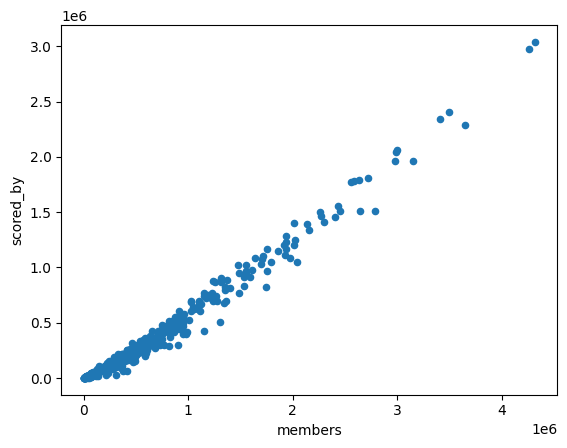

In [25]:
topRatedAnime.plot(kind='scatter', x='members', y='scored_by')

In [22]:
import pandas as pd
topRatedAnime = pd.read_csv('top_anime_dataset.csv', sep=',')
topRatedAnime.head(3)

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
0,52991,Sousou no Frieren,Frieren: Beyond Journey's End,TV,Manga,28.0,Finished Airing,False,PG-13 - Teens 13 or older,9.28,823434,1.0,108,1353494,85889,During their decade-long quest to defeat the D...,2023.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/52991/Sousou_no_...
1,59978,Sousou no Frieren 2nd Season,Frieren: Beyond Journey's End Season 2,TV,Manga,10.0,Currently Airing,True,PG-13 - Teens 13 or older,9.16,62148,2.0,644,414180,5476,"Following the First-Class Mage Exam, the trio—...",2026.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/59978/Sousou_no_...
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,2290193,3.0,3,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"Action, Adventure, Drama, Fantasy",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...


## Numerical vs Categorical

Examples:
- Monthly earnings VS Highest obtained degree
- Body length VS Country of origin
- Happiness rating VS Country of origin
- Sales VS Account Manager. 
- Revenue VS Product Category
- Revenue VS Game genre
- Retention VS Software version
- ...

In univariate analysis for numerical data we've looked at confidence intervals. We can use these as well to check if there are any signicant differences between categories.

You and I are are going to roll a 6-sided die. The numerical variable is the value we roll and the categorical variable is who rolled it. We know that in reality the average value of a 6-sided die is 3.5 (=(1+2+3+4+5+6)/6). We know that there is no skill involved, so who rolls the die should have no impact on the result. We each roll the die 3 times.
    <img src="https://wherethewindsblow.com/wp-content/uploads/2015/07/JUMBO-Six-sided-white-dice.jpg" style="width: 300px;"/>

In [26]:
diceRolls = pd.DataFrame(data= {'Person': ['you', 'you', 'you', 'me','me','me'], 'Rolls': [6,3,6,2,4,2]})
diceRolls

,Person,Rolls
0,you,6
1,you,3
2,you,6
3,me,2
4,me,4
5,me,2


In [27]:
diceRolls.groupby(by="Person").mean()

,Rolls
Person,
me,2.666667
you,5.000000


Looks like you rolled an average value of 5 and I rolled an average value of ~2.7. Does this mean you are better at rolling dice than me?

```seaborn.barplot()``` is a function from the Seaborn library that creates a bar chart — it's great for visualizing comparisons between categories.

Unlike basic bar plots, Seaborn's barplot():
- Can automatically calculate averages if you give it multiple values per category
- Adds error bars (**by default, 95% confidence intervals**)

If you're plotting the average dice rolls per person, the bar height shows the average — and the error bar shows how much that average might vary if you repeated the experiment.
So if you hav a bar at 5, and the error bar goes from 3 to 5, it means:

**“We’re fairly confident the true average rolls for you is between 3 and 5.”**

<Axes: xlabel='Person', ylabel='Rolls'>

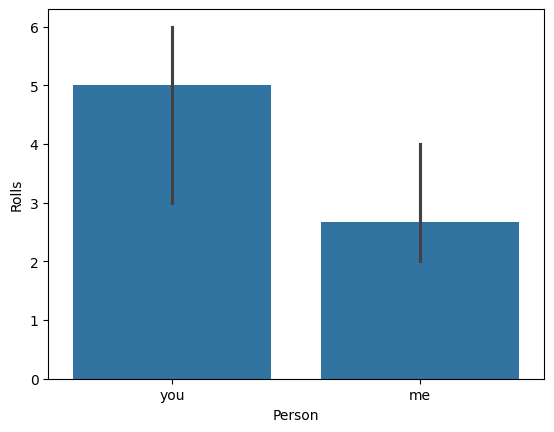

In [28]:
sns.barplot(x="Person", y="Rolls", data=diceRolls)

The confidence intervals overlap. This means that we can not yet be sure that you're a better dice roller than me. If we want the confidence intervals to become smaller, we'll need more data which means we need to do more dice rolls.

Let's look if there are significant difference between iris species.

In [29]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


<Axes: xlabel='species', ylabel='sepal_length'>

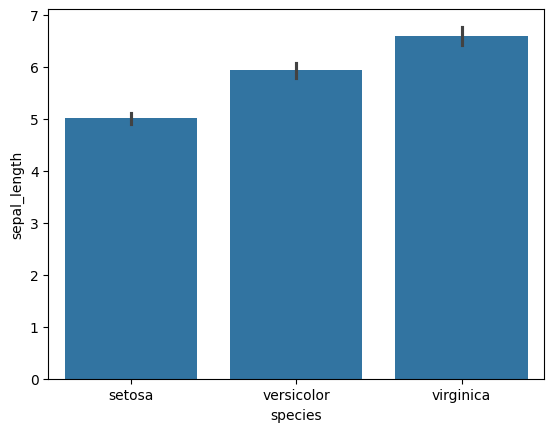

In [31]:
sns.barplot(y="sepal_length", x="species", data=iris) 
# Add parameter ci if you want to change certainty of confidence interval. 
# For example ci = 99 for 99% certainty.
# The default is 95%

<Axes: xlabel='species', ylabel='sepal_width'>

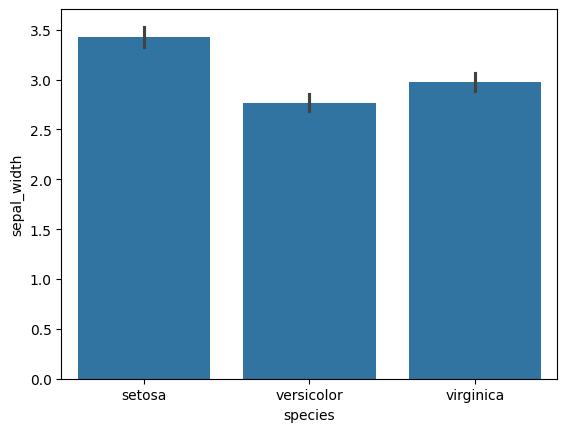

In [32]:
sns.barplot(y="sepal_width", x="species", data=iris)

<Axes: xlabel='species', ylabel='petal_length'>

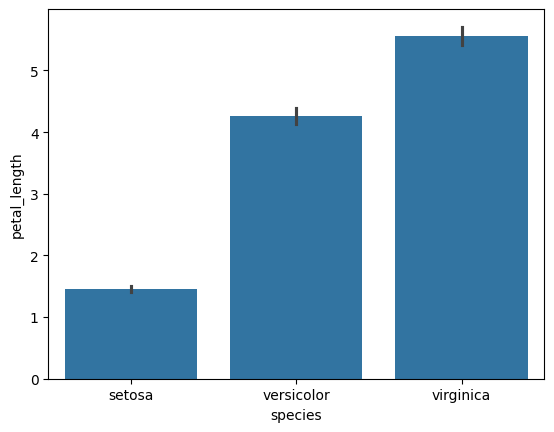

In [33]:
sns.barplot(y="petal_length", x="species", data=iris)

<Axes: xlabel='species', ylabel='petal_width'>

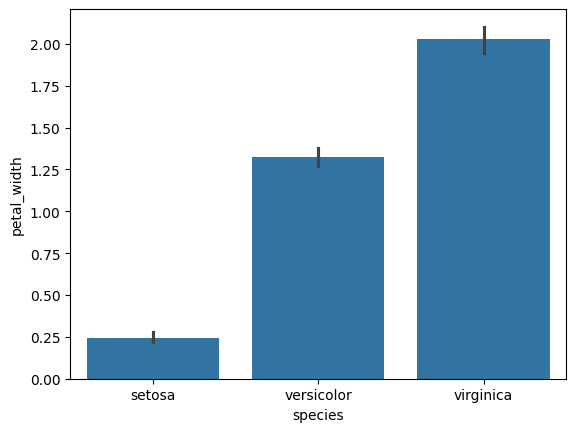

In [34]:
sns.barplot(y="petal_width", x="species", data=iris)

### Portfolio assignment 11
20 min: Do a Numerical VS Categorical bivariate analysis on the penguins dataset.
- Choose one of the categorical columns: species, island or sex
- use .groupby('<columnname>').mean() too look at the means of the numerical columns. Does it look like there is a difference between categories?
- Use the seaborn barplot to plot the mean and confidence. Create this plot for each of the numerical columns (bill_length_mm	bill_depth_mm, flipper_length_mm, body_mass_g)
- For each of the plots, write a conclusion: Is there a statistically significant difference for this numerical column for each category?
- Optional: Repeat this proces for the other two categorical columns

In [ ]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [50]:
penguins.groupby('species').mean(numeric_only=True)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


<Axes: xlabel='species', ylabel='bill_length_mm'>

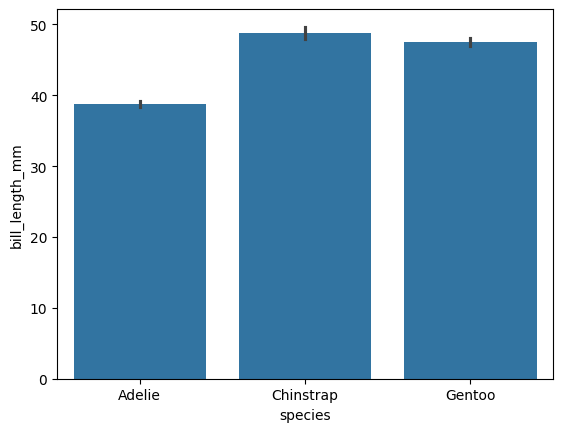

In [53]:
sns.barplot(y="bill_length_mm", x="species", data=penguins)

<Axes: xlabel='species', ylabel='bill_depth_mm'>

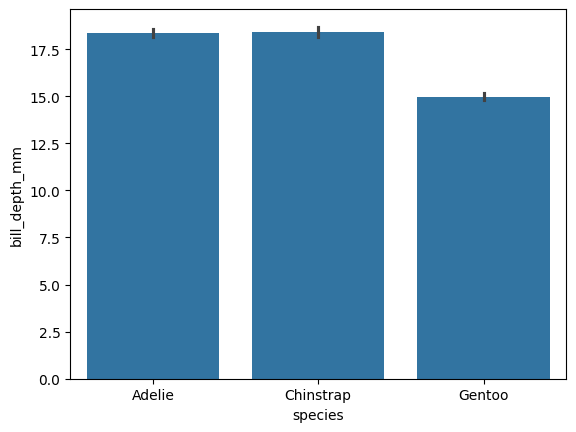

In [56]:
sns.barplot(y="bill_depth_mm", x="species", data=penguins)

<Axes: xlabel='species', ylabel='flipper_length_mm'>

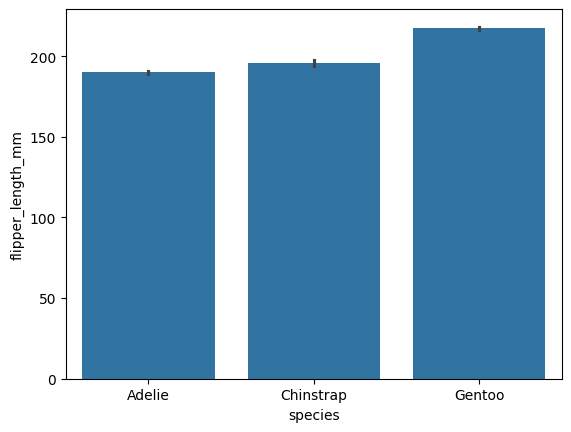

In [57]:
sns.barplot(y="flipper_length_mm", x="species", data=penguins)

<Axes: xlabel='species', ylabel='body_mass_g'>

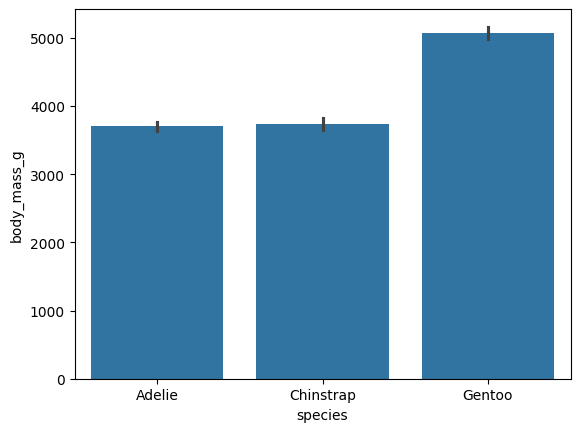

In [58]:
sns.barplot(y="body_mass_g", x="species", data=penguins)

In [51]:
penguins.groupby('island').mean(numeric_only=True)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
island,,,,
Biscoe,45.257485,15.874850,209.706587,4716.017964
Dream,44.167742,18.344355,193.072581,3712.903226
Torgersen,38.950980,18.429412,191.196078,3706.372549


In [52]:
penguins.groupby('sex').mean(numeric_only=True)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
sex,,,,
Female,42.096970,16.425455,197.363636,3862.272727
Male,45.854762,17.891071,204.505952,4545.684524


![](https://user-images.githubusercontent.com/54525819/139198017-769e8f61-2e58-48a9-947d-fd22947a6548.png)

![](https://i.imgur.com/0v1CGNV.png)<br>
Assumption: ...<br>
Findings: ...<br>

### Portfolio assignment 12
30 min: Perform a bivariate analysis on at least 3 combinations of a numerical column with a categorical column in the dataset that you chose in portfolio assignment 4. Use <em>.groupby('columnname').mean()</em> to calculate the means. Is there a difference between categories? Then use seaborn barplots to check if there is a statistically significant difference. 

In [60]:
topRatedAnime.head(1)

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
0,52991,Sousou no Frieren,Frieren: Beyond Journey's End,TV,Manga,28.0,Finished Airing,False,PG-13 - Teens 13 or older,9.28,823434,1.0,108,1353494,85889,During their decade-long quest to defeat the D...,2023.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/52991/Sousou_no_...


In [61]:
topRatedAnime.groupby('type').mean(numeric_only=True)


,mal_id,episodes,airing,score,scored_by,rank,popularity,members,favorites,year
type,,,,,,,,,,
Movie,28567.736842,1.263158,0.000000,8.410877,240013.026316,255.912281,1782.912281,407944.991228,6214.921053,NaN
Music,46150.571429,2.833333,0.142857,8.397143,42788.571429,NaN,4682.428571,66350.142857,616.142857,NaN
ONA,50646.909091,31.950000,0.136364,8.415455,53035.636364,242.272727,4709.909091,106390.795455,2294.250000,NaN
OVA,11151.882353,12.000000,0.000000,8.358235,106255.117647,295.176471,1909.823529,217356.000000,3328.411765,NaN
PV,53236.000000,1.000000,0.000000,8.380000,22622.000000,NaN,4078.000000,38856.000000,112.000000,NaN
Special,29852.444444,1.666667,0.000000,8.336667,105340.555556,284.666667,2387.000000,183190.555556,524.333333,NaN
TV,29629.612795,25.017007,0.043771,8.443401,435568.902357,240.296296,870.367003,773868.996633,20207.390572,2015.070707
TV Special,34416.636364,1.636364,0.000000,8.489091,131852.454545,229.272727,1811.181818,235060.727273,2805.090909,NaN


<Axes: xlabel='type', ylabel='score'>

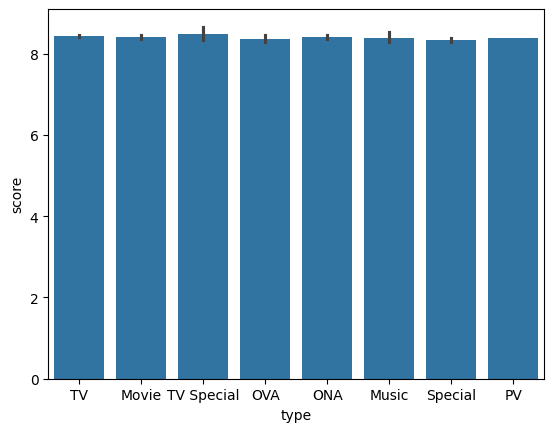

In [63]:
sns.barplot(y="score", x="type", data=topRatedAnime)

<Axes: xlabel='type', ylabel='episodes'>

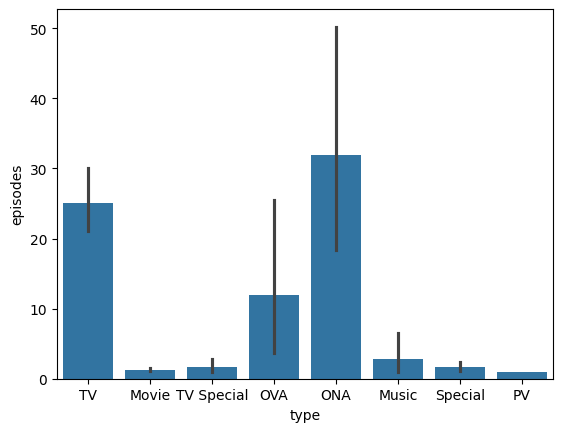

In [64]:
sns.barplot(y="episodes", x="type", data=topRatedAnime)

<Axes: xlabel='type', ylabel='members'>

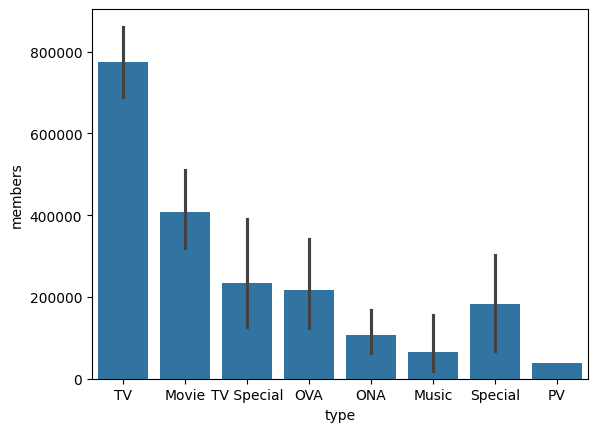

In [65]:
sns.barplot(y="members", x="type", data=topRatedAnime)

![](https://i.imgur.com/0v1CGNV.png)<br>
Assumption: ...<br>
Findings: ...<br>

## Categorical vs Categorical

Examples:
- Inbound channel VS Type of customer
- Education VS Job function
- Region of citizen VS Who the citizen votes for
- Color shirt of crew member in Stat Trek VS Does the crew member survive? (https://statisticsbyjim.com/hypothesis-testing/chi-square-test-independence-example/)
- Customer newsletter subscription (Yes/No) VS Custom churn (Yes/No)
- Penguin island VS Penguin species
- ...

![](https://d3i3l3kraiqpym.cloudfront.net/wp-content/uploads/2016/04/26094914/Ad%C3%A9lie-Chinstrap-and-gentoo-penguin-species.jpg)

<Axes: xlabel='species'>

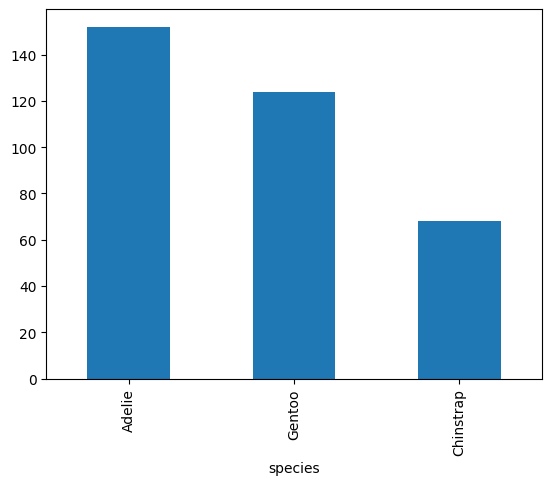

In [66]:
penguins.species.value_counts().plot(kind='bar')

<Axes: xlabel='island'>

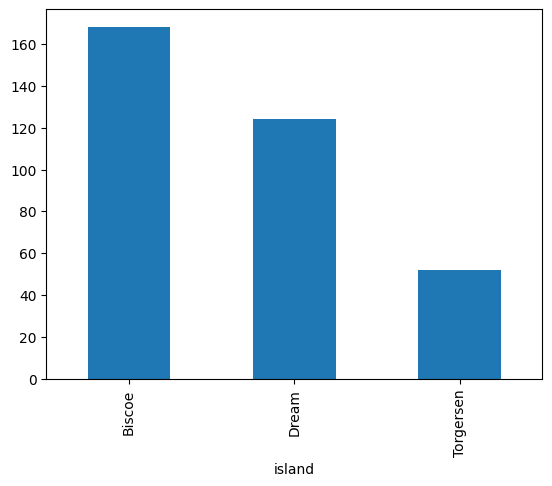

In [67]:
penguins['island'].value_counts().plot(kind='bar')

In [68]:
def create_contingency_table(dataset, column1, column2):
    return dataset.groupby([column1, column2]).size().unstack(column1, fill_value=0)

A **contingency table** (also called a cross-tabulation or crosstab) is a table used to show the frequency distribution of two (or more) categorical variables. Each cell in the table represents the count of records that have a specific combination of values from the two variables.

What does **stack() and unstack()** do in pandas?
Both are used to reshape multi-level (hierarchical) indexes:

**unstack(level)**
Pivots a level of row index into columns

Converts a MultiIndex row into a wider DataFrame

**stack(level)**
Pivots a level of columns into row index

Converts columns into a deeper row index


In [69]:
penguinsContingencyTable = create_contingency_table(penguins, 'species','island')

In [70]:
penguinsContingencyTable

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


<Axes: xlabel='island'>

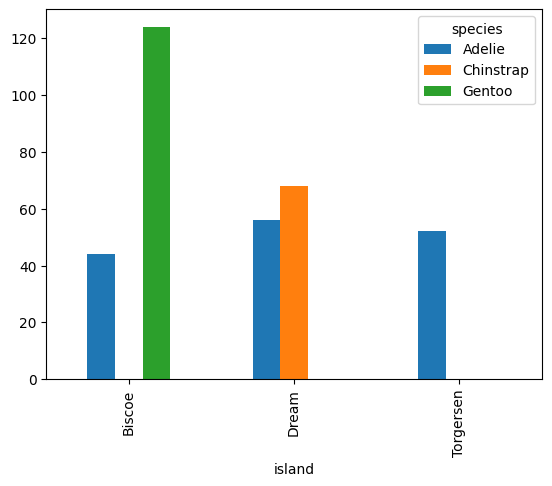

In [71]:
penguinsContingencyTable.plot(kind='bar')

In [72]:
from scipy.stats import chi2_contingency
def check_cat_vs_cat_correlation(dataset, column1, column2):
    contingency_table = create_contingency_table(dataset, column1, column2)
    chi2 = chi2_contingency(contingency_table)
    print(chi2)
    p_value = chi2[1]
    odds_of_correlation = 1 - p_value
    print(f"The odds of a correlation between {column1} and {column2} is {odds_of_correlation * 100}% (Based on a p value of {p_value}).")
    print("This percentage needs to be at least 95% for a significant correlation.")

In [73]:
check_cat_vs_cat_correlation(penguins, 'species','island')

Chi2ContingencyResult(statistic=np.float64(299.55032743148195), pvalue=np.float64(1.354573829719252e-63), dof=4, expected_freq=array([[74.23255814, 33.20930233, 60.55813953],
       [54.79069767, 24.51162791, 44.69767442],
       [22.97674419, 10.27906977, 18.74418605]]))
The odds of a correlation between species and island is 100.0% (Based on a p value of 1.354573829719252e-63).
This percentage needs to be at least 95% for a significant correlation.


The function **chi2_contingency** from scipy.stats performs the Chi-squared test of independence, which is a statistical test used to determine whether two categorical variables are independent or associated.

Given a contingency table (i.e., a cross-tab of counts between two categorical variables), **chi2_contingency checks if the observed frequencies are significantly different from the frequencies we would expect if the variables were independent**.

**Chi-squared statistic (statistic=299.55)**
This is a measure of how different the observed values are from the expected values (assuming no relationship). A large value = bigger difference.

**p-value (pvalue=1.35e-63)**
This is extremely small (almost zero), which means the probability that this difference happened by chance is effectively zero.

**Expected Frequencies**
These are the counts you would expect in each cell if there were no relationship between species and island.

*“The odds of a correlation between species and island is 100.0% (Based on a p-value of 1.35e-63). This percentage needs to be at least 95% for a significant correlation.”*

This means:

Your p-value is way below the threshold of 0.05 (which is a 95% confidence level).

Therefore, you reject the null hypothesis.

There is a statistically significant association between species and island.

In plain English: certain species are much more likely to be found on certain islands, and this pattern is not due to random chance.


![](https://1000logos.net/wp-content/uploads/2021/01/Suitmarks-of-playing-cards.jpg)

In [74]:
cardThrows = pd.DataFrame(data= {'Person': ['you', 'you', 'you', 'me','me','me'], 'Throws': ['spades','hearts','clubs','spades', 'hearts','diamonds']})

In [75]:
cardThrows

,Person,Throws
0,you,spades
1,you,hearts
2,you,clubs
3,me,spades
4,me,hearts
5,me,diamonds


In [76]:
contingencyTableCardThrows = create_contingency_table(cardThrows, 'Person','Throws')
print(contingencyTableCardThrows)

Person    me  you
Throws           
clubs      0    1
diamonds   1    0
hearts     1    1
spades     1    1


<Axes: xlabel='Throws'>

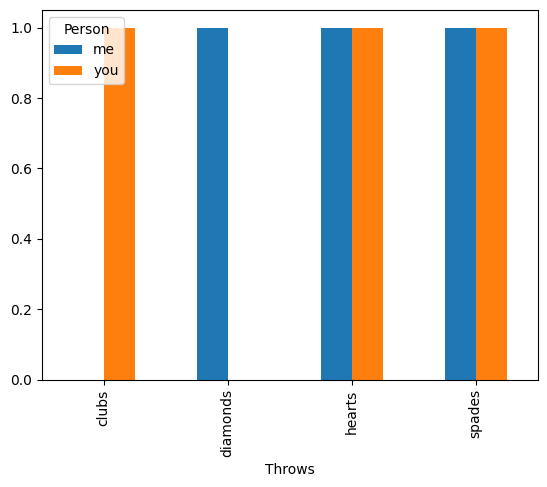

In [77]:
contingencyTableCardThrows.plot(kind='bar')

In [78]:
check_cat_vs_cat_correlation(cardThrows, 'Person','Throws')

Chi2ContingencyResult(statistic=np.float64(2.0), pvalue=np.float64(0.5724067044708798), dof=3, expected_freq=array([[0.5, 0.5],
       [0.5, 0.5],
       [1. , 1. ],
       [1. , 1. ]]))
The odds of a correlation between Person and Throws is 42.75932955291202% (Based on a p value of 0.5724067044708798).
This percentage needs to be at least 95% for a significant correlation.


![](https://miro.medium.com/max/532/1*S8rfFkmLhDbOz4RGNwuz6g.png)

In [85]:
# Change the numberOfRolls and low & high of each player to see the impact on the chi-square test.
numberOfThrows = 30
person1Throws= pd.Series( np.random.choice(['spades','hearts','clubs', 'diamonds'], size=numberOfThrows ))
person2Throws= pd.Series( np.random.choice(['spades','hearts','clubs'], size=numberOfThrows ))

cardThrows2 = pd.DataFrame({
    'Person':pd.concat([pd.Series(['Person1']*numberOfThrows),pd.Series(['Person2']*numberOfThrows)]),
    'Throws':pd.concat([person1Throws,person2Throws])
})
cardThrows2.head()

,Person,Throws
0,Person1,clubs
1,Person1,spades
2,Person1,spades
3,Person1,diamonds
4,Person1,clubs


In [86]:
contingencyTableCardThrows2 = create_contingency_table(cardThrows2, 'Person','Throws')

<Axes: xlabel='Throws'>

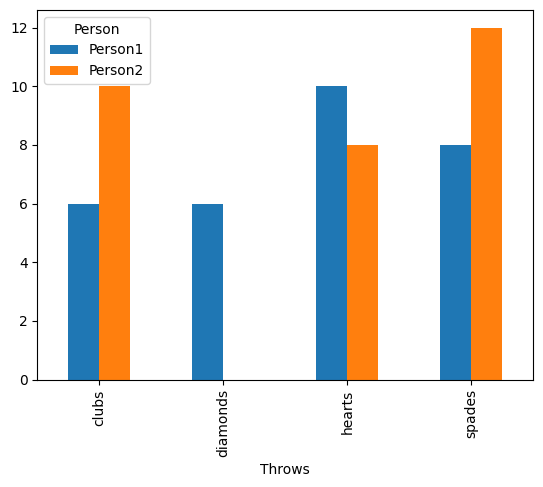

In [87]:
contingencyTableCardThrows2.plot(kind='bar')

In [88]:
check_cat_vs_cat_correlation(cardThrows2, 'Person','Throws')

Chi2ContingencyResult(statistic=np.float64(8.022222222222222), pvalue=np.float64(0.045554664967954836), dof=3, expected_freq=array([[ 8.,  8.],
       [ 3.,  3.],
       [ 9.,  9.],
       [10., 10.]]))
The odds of a correlation between Person and Throws is 95.44453350320453% (Based on a p value of 0.045554664967954836).
This percentage needs to be at least 95% for a significant correlation.


### Portfolio assignment 13
10 min: Do a bivariate analysis on the penguins dataset for the following combination of columns:
- species VS sex
- island VS sex

For this bivariate analysis, at least perform the following tasks:
- Do you expect their to be a correlation between the two columns?
- Create a contingency table. Do you observe different ratios between categories here?
- Create a bar plot for this contingency table. Do you observe different ratios between categories here?
- Do a chi-squared test. What does the result say? What's the chance of there being a correlation between the two columns?

In [96]:
def create_contingency_table(dataset, column1, column2):
    return dataset.groupby([column1, column2]).size().unstack(column1, fill_value=0)

In [100]:

penguinsContingencyTable = create_contingency_table(penguins, 'species','sex')

In [101]:
penguinsContingencyTable

species,Adelie,Chinstrap,Gentoo
sex,,,
Female,73,34,58
Male,73,34,61


<Axes: xlabel='sex'>

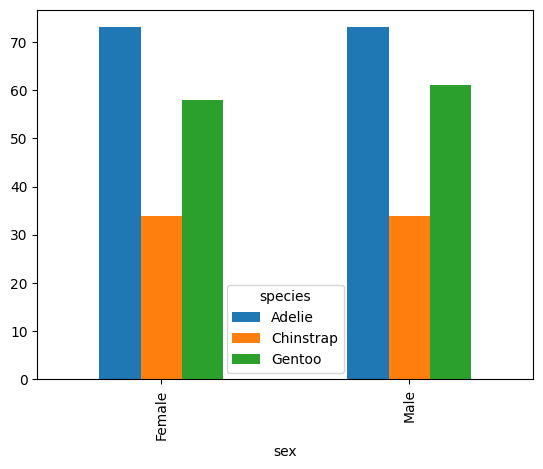

In [102]:
penguinsContingencyTable.plot(kind='bar')

In [90]:
from scipy.stats import chi2_contingency
def check_cat_vs_cat_correlation(dataset, column1, column2):
    contingency_table = create_contingency_table(dataset, column1, column2)
    chi2 = chi2_contingency(contingency_table)
    print(chi2)
    p_value = chi2[1]
    odds_of_correlation = 1 - p_value
    print(f"The odds of a correlation between {column1} and {column2} is {odds_of_correlation * 100}% (Based on a p value of {p_value}).")
    print("This percentage needs to be at least 95% for a significant correlation.")

In [109]:
check_cat_vs_cat_correlation(penguins, 'species','sex')

Chi2ContingencyResult(statistic=np.float64(0.04860717014078319), pvalue=np.float64(0.9759893689765846), dof=2, expected_freq=array([[72.34234234, 33.69369369, 58.96396396],
       [73.65765766, 34.30630631, 60.03603604]]))
The odds of a correlation between species and sex is 2.4010631023415385% (Based on a p value of 0.9759893689765846).
This percentage needs to be at least 95% for a significant correlation.


In [104]:
penguinsContingencyTable = create_contingency_table(penguins, 'island','sex')

In [105]:
penguinsContingencyTable

island,Biscoe,Dream,Torgersen
sex,,,
Female,80,61,24
Male,83,62,23


<Axes: xlabel='sex'>

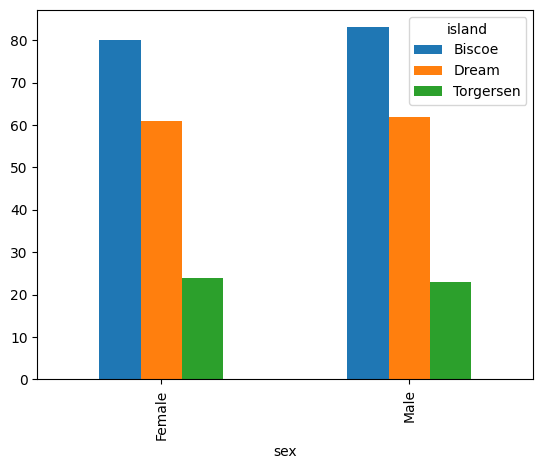

In [106]:
penguinsContingencyTable.plot(kind='bar')

In [107]:
check_cat_vs_cat_correlation(penguins, 'island','sex')

Chi2ContingencyResult(statistic=np.float64(0.05759904881286206), pvalue=np.float64(0.971611229281065), dof=2, expected_freq=array([[80.76576577, 60.94594595, 23.28828829],
       [82.23423423, 62.05405405, 23.71171171]]))
The odds of a correlation between island and sex is 2.8388770718934975% (Based on a p value of 0.971611229281065).
This percentage needs to be at least 95% for a significant correlation.


![](https://i.imgur.com/0v1CGNV.png)<br>
Assumptions: ...<br>
Findings: ...<br>

### Portfolio assignment 14
Perform a bivariate analysis on at least 1 combination of 2 columns with categorical data in the dataset that you chose in portfolio assignment 4.
- Do you expect their to be a correlation between the two columns?
- Create a contingency table. Do you observe different ratios between categories here?
- Create a bar plot for this contingency table. Do you observe different ratios between categories here?
- Do a chi-squared test. What does the result say? What's the chance of there being a correlation between the two columns?

In [110]:
def create_contingency_table(dataset, column1, column2):
    return dataset.groupby([column1, column2]).size().unstack(column1, fill_value=0)

In [122]:
animeContingencyTable = create_contingency_table(topRatedAnime, 'source','rating')

In [123]:
animeContingencyTable

source,4-koma manga,Book,Game,Light novel,Manga,Mixed media,Music,Novel,Original,Other,Visual novel,Web manga,Web novel
rating,,,,,,,,,,,,,
G - All Ages,0,1,0,0,5,0,0,2,4,1,0,1,0
PG - Children,0,0,1,0,4,0,0,0,2,0,0,0,0
PG-13 - Teens 13 or older,4,0,4,22,191,1,0,11,39,2,7,11,21
R - 17+ (violence & profanity),0,0,0,31,73,0,1,7,18,0,6,8,4
R+ - Mild Nudity,0,0,1,1,7,0,0,3,5,1,0,0,0


<Axes: xlabel='rating'>

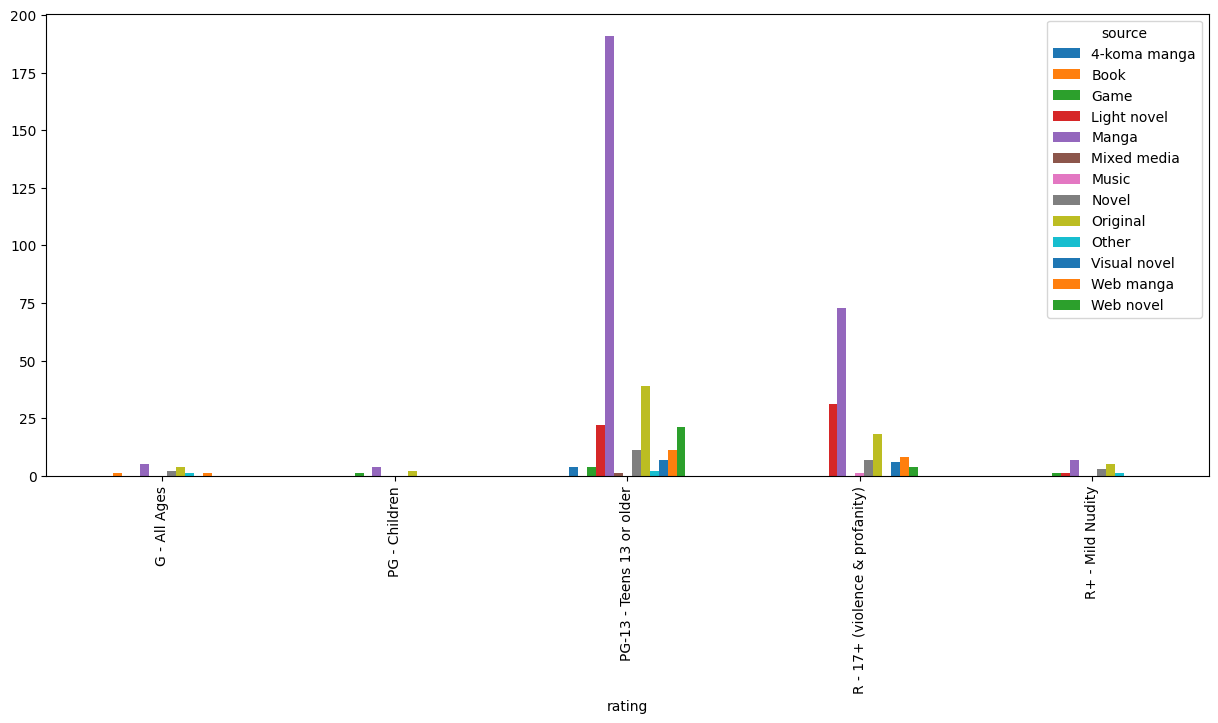

In [126]:
animeContingencyTable.plot(kind='bar', figsize=(15,6))

In [127]:
check_cat_vs_cat_correlation(topRatedAnime, 'source','rating')

Chi2ContingencyResult(statistic=np.float64(120.16498653357073), pvalue=np.float64(4.056291039817038e-08), dof=48, expected_freq=array([[1.1200e-01, 2.8000e-02, 1.6800e-01, 1.5120e+00, 7.8400e+00,
        2.8000e-02, 2.8000e-02, 6.4400e-01, 1.9040e+00, 1.1200e-01,
        3.6400e-01, 5.6000e-01, 7.0000e-01],
       [5.6000e-02, 1.4000e-02, 8.4000e-02, 7.5600e-01, 3.9200e+00,
        1.4000e-02, 1.4000e-02, 3.2200e-01, 9.5200e-01, 5.6000e-02,
        1.8200e-01, 2.8000e-01, 3.5000e-01],
       [2.5040e+00, 6.2600e-01, 3.7560e+00, 3.3804e+01, 1.7528e+02,
        6.2600e-01, 6.2600e-01, 1.4398e+01, 4.2568e+01, 2.5040e+00,
        8.1380e+00, 1.2520e+01, 1.5650e+01],
       [1.1840e+00, 2.9600e-01, 1.7760e+00, 1.5984e+01, 8.2880e+01,
        2.9600e-01, 2.9600e-01, 6.8080e+00, 2.0128e+01, 1.1840e+00,
        3.8480e+00, 5.9200e+00, 7.4000e+00],
       [1.4400e-01, 3.6000e-02, 2.1600e-01, 1.9440e+00, 1.0080e+01,
        3.6000e-02, 3.6000e-02, 8.2800e-01, 2.4480e+00, 1.4400e-01,
        4.68

![](https://i.imgur.com/0v1CGNV.png)<br>
Assumption: ...<br>
Finding: ...<br>